In [10]:
import sys
sys.path.append("..")

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

import autoimmune_analysis.TCR_diversity_metrics as dm
import autoimmune_analysis.TCR_utils as funcs

import re
import gdown
import tarfile

link = 'https://drive.google.com/file/d/1F0lG7-75RYOUBOmnxsbJyyBxJdB44i3N/view?usp=drive_link'
output = '../data/mixcr.tar.gz'

gdown.download(link, output, quiet=False)

with tarfile.open('../data/mixcr.tar.gz', 'r') as tar:
    tar.extractall(path='../data/mixcr_clonotypes/')

Downloading...
From (original): https://drive.google.com/uc?id=1F0lG7-75RYOUBOmnxsbJyyBxJdB44i3N
From (redirected): https://drive.google.com/uc?id=1F0lG7-75RYOUBOmnxsbJyyBxJdB44i3N&confirm=t&uuid=d0faf314-7f61-4f00-ad0f-c4a501b97c57
To: /home/bioinf2026/sko1/MiXCR_processing/SKO-1/data/mixcr.tar.gz
100%|██████████| 551M/551M [00:11<00:00, 46.3MB/s] 


# TCR Repertoire diversity metrics analysis

One of the first steps in immune repertoire analysis is diversity quantification and evaluation. For that we calculated several diversity indices, like Shannon, Chao1 and Clonality. In addition to that we looked at the number of observed clonotypes and numbers of total mapped reads per sample. 

This notebook looks at the diversity metrics of all 4 TCR genes that encode alpha, beta, gamma and delta chains. Subsequent reperotire analysis is focused on the beta chain only as it is known to make the most contribution in alpha-beta T-cell diversity and specificity.

## Preparing the data

First of all we must prepare filename lists for the TCR genes, then process each gene separately by loading their corresponding reports and calculating the mentioned above indices. After that we will be looking at the resulting metrics distribution across given datasets and diagnosis groups.

In [15]:
metadata_path = "../data/metadata_ifn_predictions.csv"
results_path = "../data/mixcr_clonotypes/data"
genes = ["TRB", "TRA", "TRD", "TRG"]

metadata = pd.read_csv(metadata_path)

files = funcs.get_files_dict(
    results_dir = results_path,
    genes = genes,
    metadata = metadata)

records = {}
diversity_metrics = {}

for gene in genes:
    records[gene] = []
    for file in files[gene]:
        sample = re.search(r"SRR\d+", file).group(0)
        report = pd.read_csv(file, sep="\t")

        report = dm.Report(report, counts_col="readCount")
        records[gene].append({"SRR": sample, **report.calculate_metrics()})

    diversity_metrics[gene] = pd.DataFrame(records[gene])

    diversity_metrics[gene] = metadata.merge(diversity_metrics[gene], on = "SRR")

diversity_metrics["TRB"].head()

,SRR,GSE,object,diagnosis,sex,age,ethnicity,RNA_type,treatment,disease_type,...,Batch_GMM_Harmony_k3,Final_Batch,IFN_Activity_Score,predicted_ifn_status,Total_reads,N_obs,Shannon,Chao1,Clonality,Simpson
0,SRR10342368,GSE139350,PBMC,SLE,F,47.0,NaN,polyA,NaN,SLE,...,1,1,0.06,Low,334.0,243,5.391013,572.531915,0.018578,0.994855
1,SRR10342369,GSE139350,PBMC,SLE,F,38.0,NaN,polyA,NaN,SLE,...,1,1,0.47,Low,3613.0,1200,5.684418,2437.438034,0.198257,0.973876
2,SRR10342370,GSE139350,PBMC,H,F,45.0,NaN,polyA,NaN,H,...,0,0,0.00,Low,3359.0,1616,6.235613,4226.062718,0.155948,0.988226
3,SRR10342371,GSE139350,PBMC,H,F,37.0,NaN,polyA,NaN,H,...,1,1,0.00,Low,1844.0,1174,6.674702,2774.356522,0.055668,0.996047
4,SRR12794681,GSE159225,Leukocytes,MS,M,NaN,NaN,total,NaN,RR MS,...,2,2,0.00,Low,681.0,466,5.898640,1116.197802,0.039964,0.994935


## Heatmaps

The primary analysis started with visual exploration of the calculated diversity indices through heatmaps.

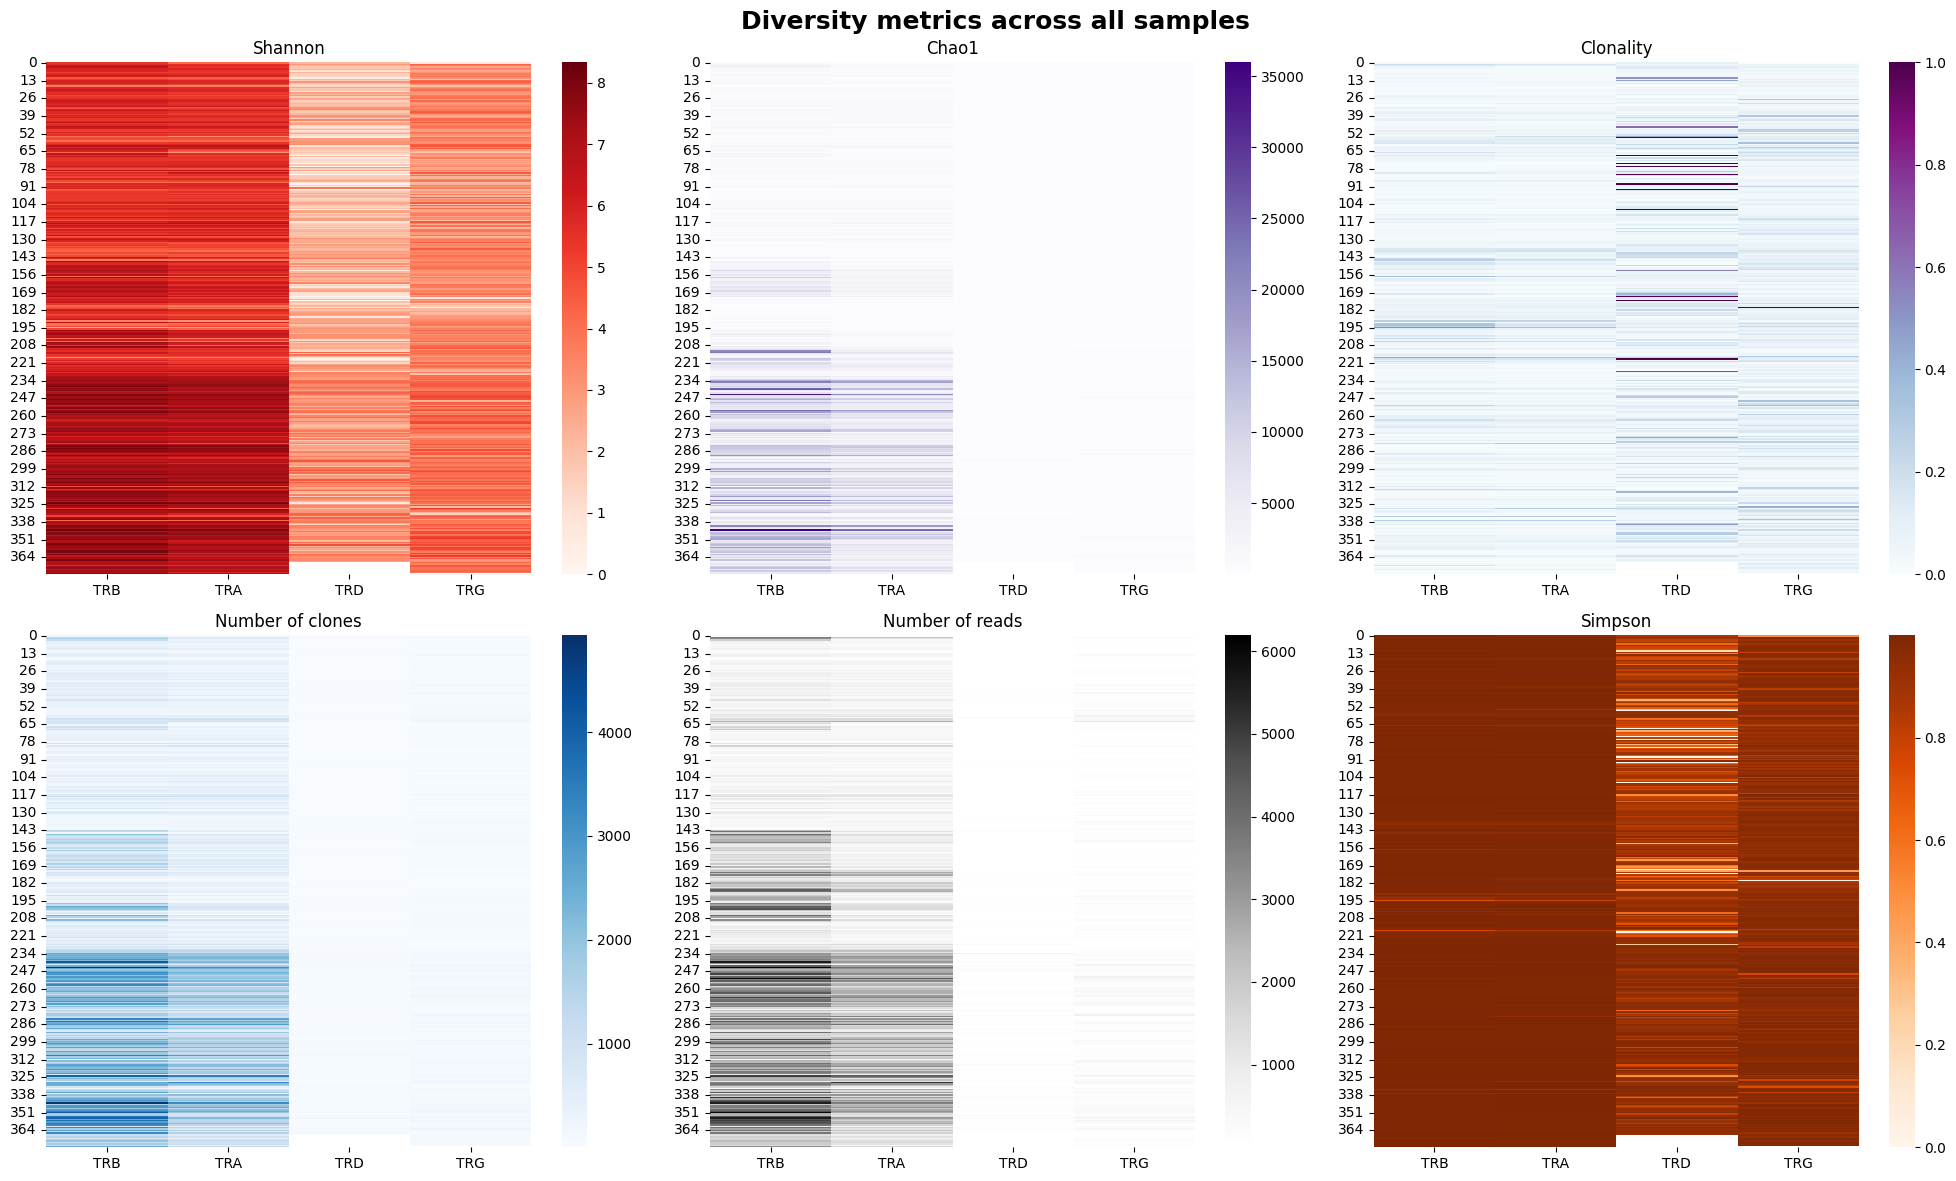

In [16]:
def get_hmp_table(metric: str, diversity_tables: dict = diversity_metrics):  
    indices = [gene[metric] for gene in diversity_metrics.values()]
    indices = dict(zip(genes, indices))
    indices = pd.DataFrame(indices)

    return indices

metric_tables = {
    "Shannon": get_hmp_table("Shannon"),
    "Chao1": get_hmp_table("Chao1"),
    "Clonality": get_hmp_table("Clonality"),
    "Number of clones": get_hmp_table("N_obs"),
    "Number of reads": get_hmp_table("Total_reads"),
    "Simpson": get_hmp_table("Simpson")
}

fig, axes = plt.subplots(2, 3, figsize = (20, 12))
axes = axes.flatten()

cmaps = ["Reds", "Purples", "BuPu", "Blues", "Greys", "Oranges"]

for (metric, table), ax, cmap in zip(metric_tables.items(), axes, cmaps): 
    sns.heatmap(
            data=table,
            ax=ax,
            cmap=cmap
        )
    ax.set_title(metric)

plt.suptitle("Diversity metrics across all samples", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

Almost all Simpson indices are close to 1 for all genes. At the same time it can be noted that TRB and TRA genes got more reads mapped to them then TRD and TRG. This can be explained by gamma-delta T-cells being less present in blood and more in peripheral tissues as well as alpha-beta T-cells being the dominant T-cell type in adults.

It is also worth noticing that there might be some correlation between the number of reads the diversity metrics such as number of clones, Chao1 and Shannon index. And some clusterisation can be seen across these 4 parameters so this should be investigated further.

## Correlation between number of reads and diversity indices

We will be using Spearman's correlation coefficient in order to define whether such correlation really takes place or not for TRA and TRB genes.

In [17]:
print("For TRB gene:")
for metric in ["Shannon", "Chao1", "Clonality"]:
    corr_result = spearmanr(
        a = diversity_metrics["TRB"]["Total_reads"],
        b = diversity_metrics["TRB"][metric]
    )
    print(f"Total reads and {metric}")
    print(f"\tSpearman's correlation coef.: {corr_result[0]:.4f}")
    print(f"\tp-value: {corr_result[1]:.4f}")
    print()

For TRB gene:
Total reads and Shannon
	Spearman's correlation coef.: 0.7624
	p-value: 0.0000

Total reads and Chao1
	Spearman's correlation coef.: 0.7239
	p-value: 0.0000

Total reads and Clonality
	Spearman's correlation coef.: 0.2158
	p-value: 0.0000



In [18]:
print("For TRA gene:")
for metric in ["Shannon", "Chao1", "Clonality"]:
    corr_result = spearmanr(
        a = diversity_metrics["TRA"]["Total_reads"],
        b = diversity_metrics["TRA"][metric]
    )
    print(f"Total reads and {metric}")
    print(f"\tSpearman's correlation coef.: {corr_result[0]:.4f}")
    print(f"\tp-value: {corr_result[1]:.4f}")
    print()

For TRA gene:
Total reads and Shannon
	Spearman's correlation coef.: 0.8130
	p-value: 0.0000

Total reads and Chao1
	Spearman's correlation coef.: 0.7284
	p-value: 0.0000

Total reads and Clonality
	Spearman's correlation coef.: 0.1477
	p-value: 0.0040



So it is true that the calculated indices correlate with the number of mapped reads. Considering the visible bias of read number towards certain sample groups a batch effect might take place.

## Batch-effect check

If a number of reads is showing a clear connection to the dataset the initial report came from, than it should become visible by looking at total read number distribution between datasets. 

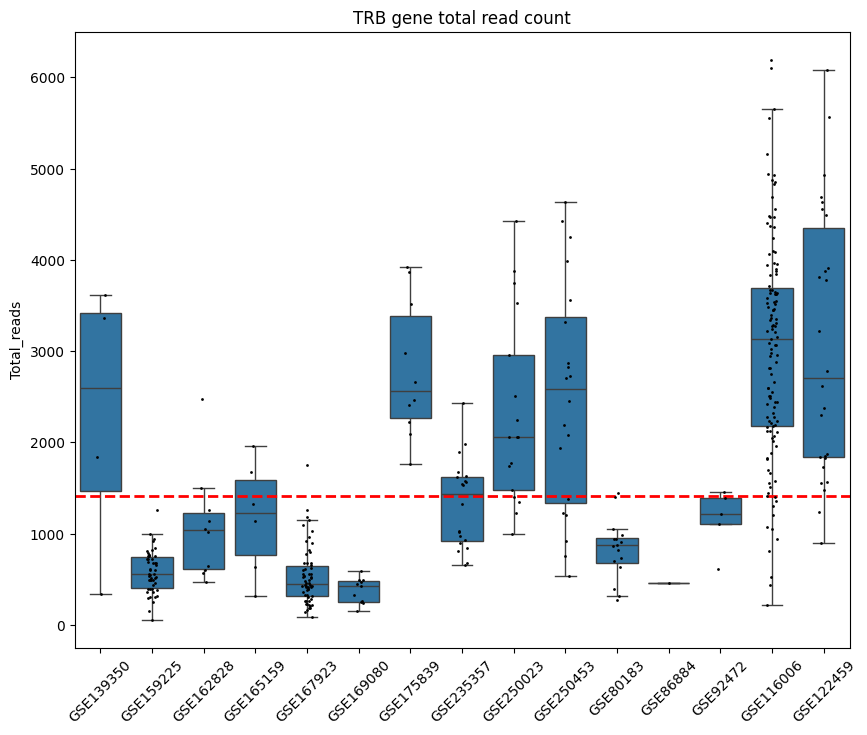

In [19]:
cur_data = diversity_metrics["TRB"]
med = cur_data["Total_reads"].median()

plt.figure(figsize=(10, 8))
sns.boxplot(
        data = cur_data,
        x="GSE",
        y="Total_reads",
        showfliers=False,
        legend = False
    )

sns.stripplot(
        data = cur_data,
        x="GSE",
        y="Total_reads",
        color="black",
        size=2,
        legend=False
    )

plt.axhline(y=med, color="red", linestyle="--", linewidth=2)
plt.xlabel("")

plt.title(f"TRB gene total read count")
plt.tick_params(axis='x', rotation=45)
plt.show()

It can be seen that batches do separate in 2 groups. The first group seems to have median read number lower than the common median, while the other datasets demonstrate higher sequencing depth. It is also connected to the RNA-type that was sequenced:

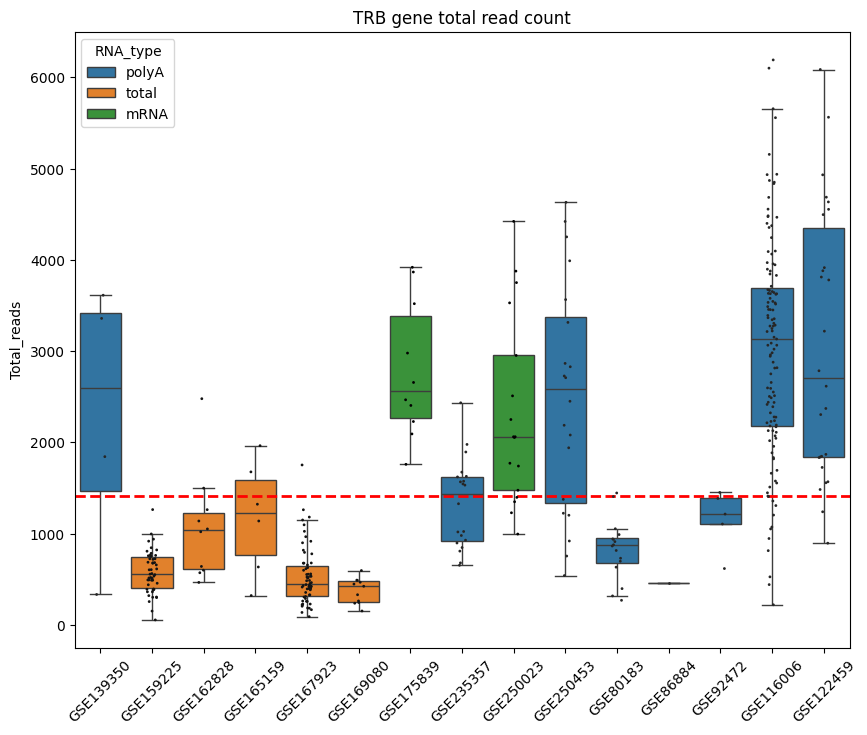

In [20]:
cur_data = diversity_metrics["TRB"]
med = cur_data["Total_reads"].median()

plt.figure(figsize=(10, 8))
sns.boxplot(
        data = cur_data,
        x="GSE",
        y="Total_reads",
        hue = "RNA_type",
        showfliers=False
    )

sns.stripplot(
        data = cur_data,
        x="GSE",
        y="Total_reads",
        palette="dark:black",
        hue="RNA_type",
        size=2,
        legend=False
    )

plt.axhline(y=med, color="red", linestyle="--", linewidth=2)
plt.xlabel("")

plt.title(f"TRB gene total read count")
plt.tick_params(axis='x', rotation=45)
plt.show()

It is probable that polyA-enriched and mRNA sequencing data show higher coverage and sequencing depth for TCR genes due to the lower number of non-protein-coding RNAs in the samples. Thus datasets that use total bulk RNA sequencing demonstrate lower read numbers and this in turn lowers the observed diversity metrics for TCR reperoire.

This batch-effect imposes certain restrictions on repertoire analysis that need will be accounted for in beta-chain repertoire research for this project.

For the subsequent analysis we used data for the beta-chain of T-cell receptor, the analysis is presented in `TCR_02_beta_chain_genes_usage.ipynb` notebook.